# S1 · Where the model is wrong

The model check of section 1 of the main notebook, taken further: the probability
distributions, measured against predicted counts, and the false positives and false
negatives at the rate-matched cut, by class, by chemistry and on the tree.

Run `../figure2_activation_code.ipynb` first; the second half reads its
`Tables/exp_pred_common_pairs.csv`.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")   # library deprecation notices only
%config InlineBackend.figure_format = 'png'

REPO = Path("../../../..").resolve()
sys.path.append(str(REPO / "Downstream_Analysis/scripts"))
sys.path.append(str(REPO / "scripts"))
import activation_code as ac
import activation_figures as af
from plotting_functions import FIGSIZE, custom_plots

plt.rcParams.update(custom_plots())

PROBABILITIES = REPO / "Downstream_Analysis/predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
M2OR_PAIRS = REPO / "Model_Inputs/Data_Preparation/processed/m2or_pairs_model.csv"
ODOURS = REPO / "Chemicals/processed_data/m2or_inchi_odors_smiles.csv"
PATHWAYS = REPO / "Chemicals/processed_data/ligand_pathways.csv"
FASTA = REPO / "Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
TREE = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"

FIGURES = Path("Figures")
TABLES = Path("Tables")
MAIN_TABLES = Path("../Tables")     # written by ../figure2_activation_code.ipynb
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)
NAME = "hybrid_density"

import seaborn as sns
from scipy import stats

common_pairs, probability_grid, human_probabilities, human_pairs = ac.tested_pairs_table(PROBABILITIES, M2OR_PAIRS, FASTA)
CUT = ac.rate_matched_cut(common_pairs["probability"].values, common_pairs["experimental"].values)
common_pairs["predicted"] = (common_pairs["probability"] > CUT).astype(int)
predicted_grid = (probability_grid > CUT).astype(int)
print(f"rate-matched cut {CUT:.4f}   measured pairs {len(common_pairs):,}")

rate-matched cut 0.9150   measured pairs 23,782


## Every predicted probability on the grid

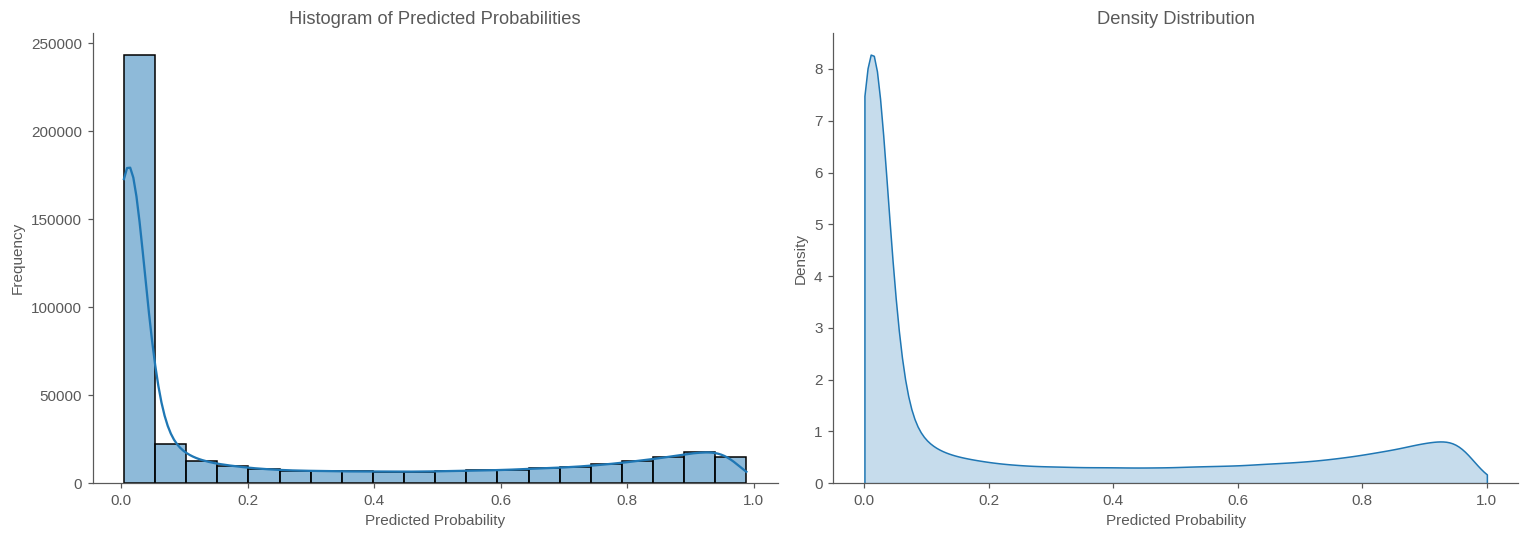

In [2]:
probabilities = pd.read_csv(PROBABILITIES)
probabilities_long = probabilities.melt(id_vars="protein_id", var_name="smiles", value_name="probability")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=probabilities_long, x="probability", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Histogram of Predicted Probabilities")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Frequency")
sns.kdeplot(data=probabilities_long, x="probability", fill=True, bw_adjust=1, clip=(0, 1), ax=axes[1])
axes[1].set_title("Density Distribution")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURES / "probability_distribution_all_pairs.svg", bbox_inches="tight")
plt.show()

## M2OR mutant flag against SwissProt

Some M2OR records flagged as mutant have exactly the SwissProt sequence of the receptor, and
for those receptors M2OR's wild type differs from SwissProt. We follow SwissProt, which is what
the predictions use, so the flag is not applied and these pairs stay in as wild type. The list
goes to `Tables/m2or_swissprot_discordance.csv`.

In [3]:
from Bio import SeqIO

m2or = pd.read_csv(M2OR_PAIRS)
swissprot_sequences = {str(record.seq) for record in SeqIO.parse(FASTA, "fasta")}
human = m2or["Species"] == "homo sapiens"
flagged_mutant = m2or[human & m2or["mutation"]]
discordant = (flagged_mutant[flagged_mutant["Sequence"].isin(swissprot_sequences)]
              [["UniProt ID", "seq_id", "Sequence"]]
              .drop_duplicates("Sequence")
              .rename(columns={"UniProt ID": "uniprot_id", "Sequence": "m2or_mutant_sequence_matches_swissprot"}))
m2or_wild_type = (m2or[human & ~m2or["mutation"]][["UniProt ID", "Sequence"]]
                  .drop_duplicates("UniProt ID")
                  .rename(columns={"UniProt ID": "uniprot_id", "Sequence": "m2or_wt_sequence"}))
discordant = discordant.merge(m2or_wild_type, on="uniprot_id", how="left")
discordant.to_csv(TABLES / "m2or_swissprot_discordance.csv", index=False)
print(f"receptors where M2OR and SwissProt disagree: {len(discordant)}")
print(discordant[["uniprot_id", "seq_id"]].to_string(index=False))

receptors where M2OR and SwissProt disagree: 5
uniprot_id  seq_id
    Q8TCB6 SEQ0099
    Q8NGR9 SEQ0420
    Q8NGJ2 SEQ0493
    Q8NGC5 SEQ0781
    Q8NGH7 SEQ0926


## Probability by measured label

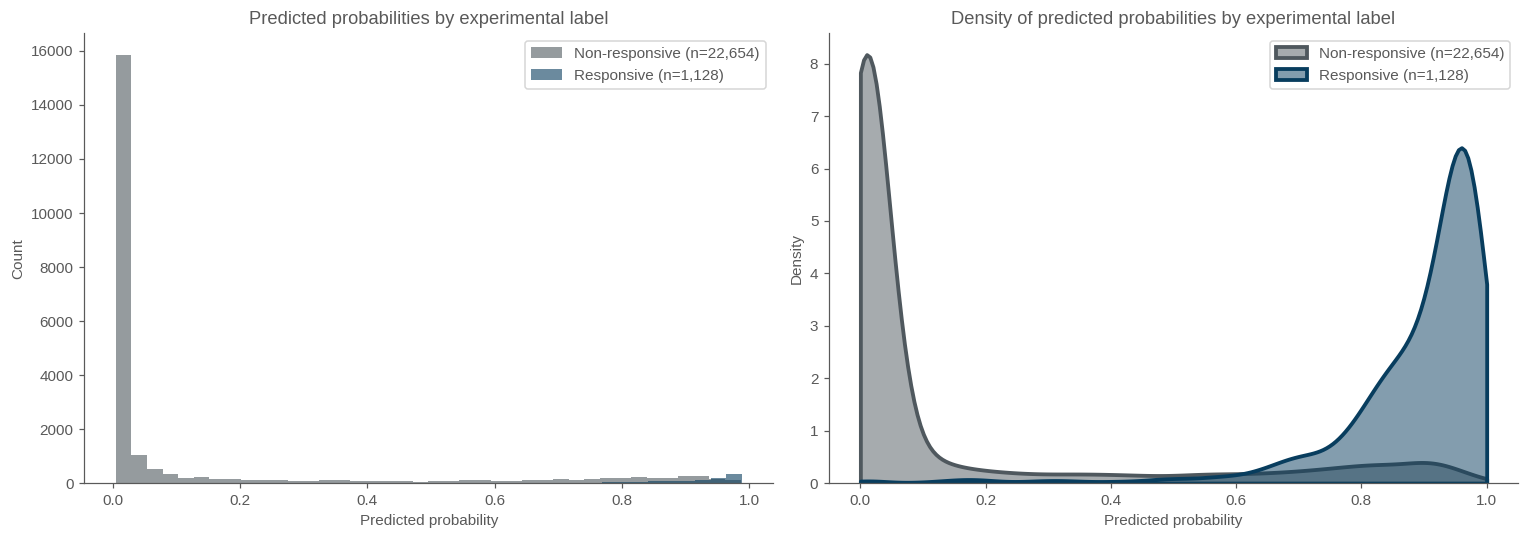

In [4]:
n_negative = (common_pairs["experimental"] == 0).sum()
n_positive = (common_pairs["experimental"] == 1).sum()
palette = {0: "#4f585e", 1: "#083d5e"}
label_names = {0: f"Non-responsive (n={n_negative:,})", 1: f"Responsive (n={n_positive:,})"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, group in common_pairs.groupby("experimental"):
    axes[0].hist(group["probability"], bins=40, alpha=0.6, color=palette[label], label=label_names[label],
                 edgecolor="none")
axes[0].set_title("Predicted probabilities by experimental label")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Count")
axes[0].legend()
for label, group in common_pairs.groupby("experimental"):
    sns.kdeplot(group["probability"], fill=True, alpha=0.5, linewidth=2.5, color=palette[label],
                label=label_names[label], bw_adjust=1, clip=(0, 1), ax=axes[1])
axes[1].set_title("Density of predicted probabilities by experimental label")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Density")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES / "probability_by_measured_label.svg", bbox_inches="tight")
plt.show()

## Measured against predicted counts

Measured counts use the measured pairs only. Predicted counts use the whole grid of receptors
and odorants that have any measurement, at the rate-matched cut.

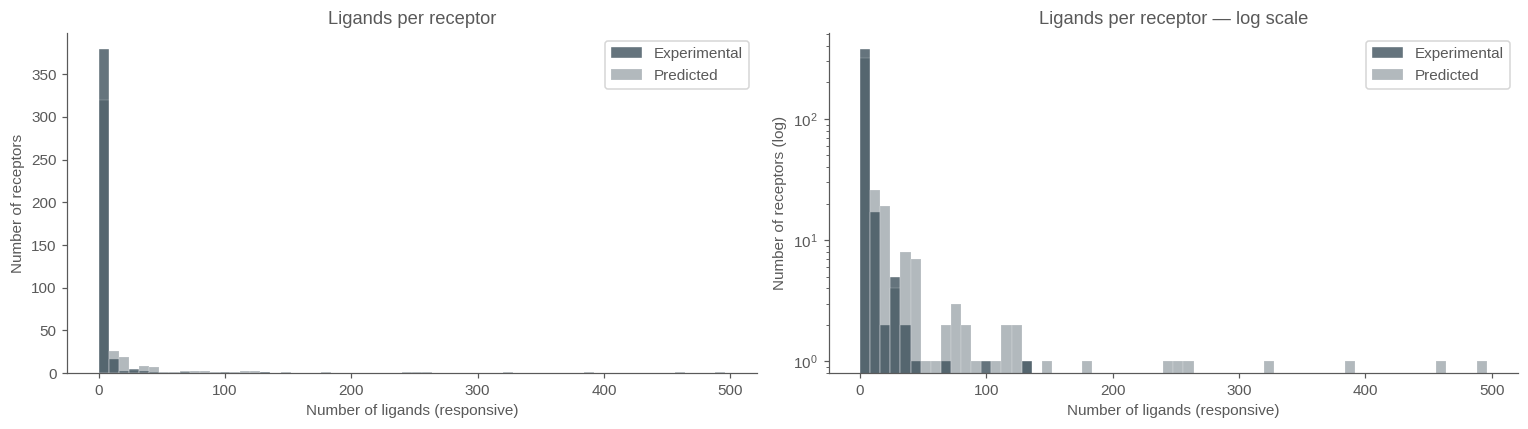

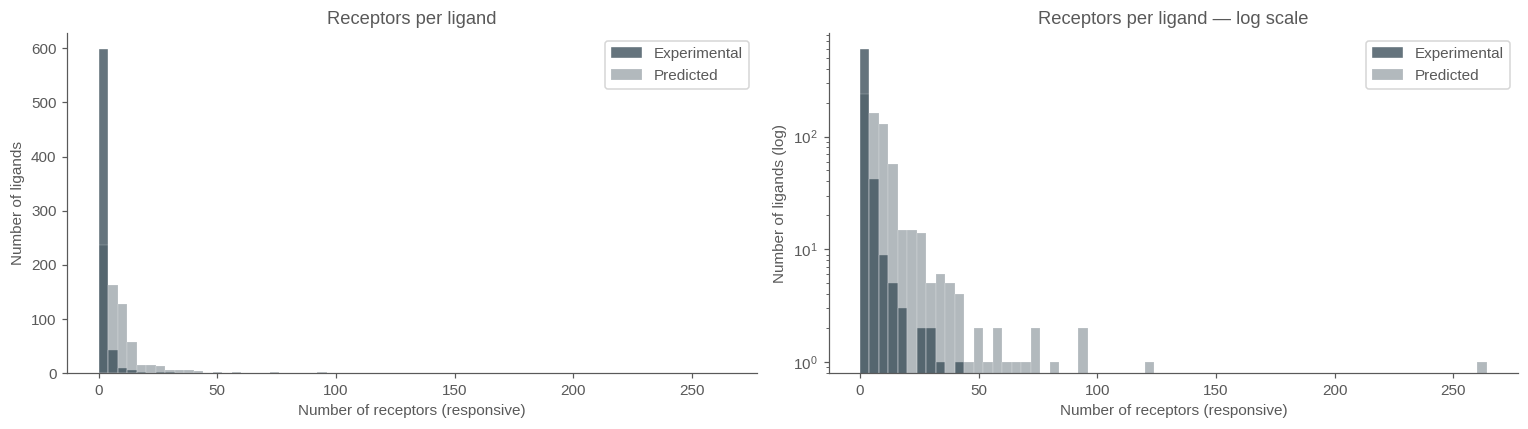

In [5]:
common_sequences = probability_grid.index
common_odorants = probability_grid.columns
positives = common_pairs[common_pairs["experimental"] == 1]


def measured_vs_predicted_histogram(measured, predicted, xlabel, ylabel, title, path):
    largest = int(max(measured.max(), predicted.max()))
    step = max(1, largest // 60)
    bins = np.arange(0, largest + step + 1, step)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, log in zip(axes, [False, True]):
        ax.hist(measured.values, bins=bins, alpha=0.8, color="#3f515c", label="Experimental", edgecolor="white",
                linewidth=0.3)
        ax.hist(predicted.values, bins=bins, alpha=0.4, color="#3f515c", label="Predicted", edgecolor="white",
                linewidth=0.3)
        ax.set_xlabel(xlabel)
        ax.legend()
        if log:
            ax.set_yscale("log")
            ax.set_ylim(bottom=0.8)
            ax.set_ylabel(f"{ylabel} (log)")
            ax.set_title(f"{title} — log scale")
        else:
            ax.set_ylabel(ylabel)
            ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()


ligands_measured = positives.groupby("sequence")["smiles_id"].count().reindex(pd.Index(common_sequences), fill_value=0)
measured_vs_predicted_histogram(ligands_measured, predicted_grid.sum(axis=1), "Number of ligands (responsive)",
                                "Number of receptors", "Ligands per receptor", FIGURES / "ligands_per_receptor.svg")

receptors_measured = positives.groupby("smiles_id")["sequence"].count().reindex(pd.Index(common_odorants), fill_value=0)
measured_vs_predicted_histogram(receptors_measured, predicted_grid.sum(axis=0), "Number of receptors (responsive)",
                                "Number of ligands", "Receptors per ligand", FIGURES / "receptors_per_ligand.svg")

## Binding proportion per odorant (the per-receptor version is Extended Data Fig. 2d)

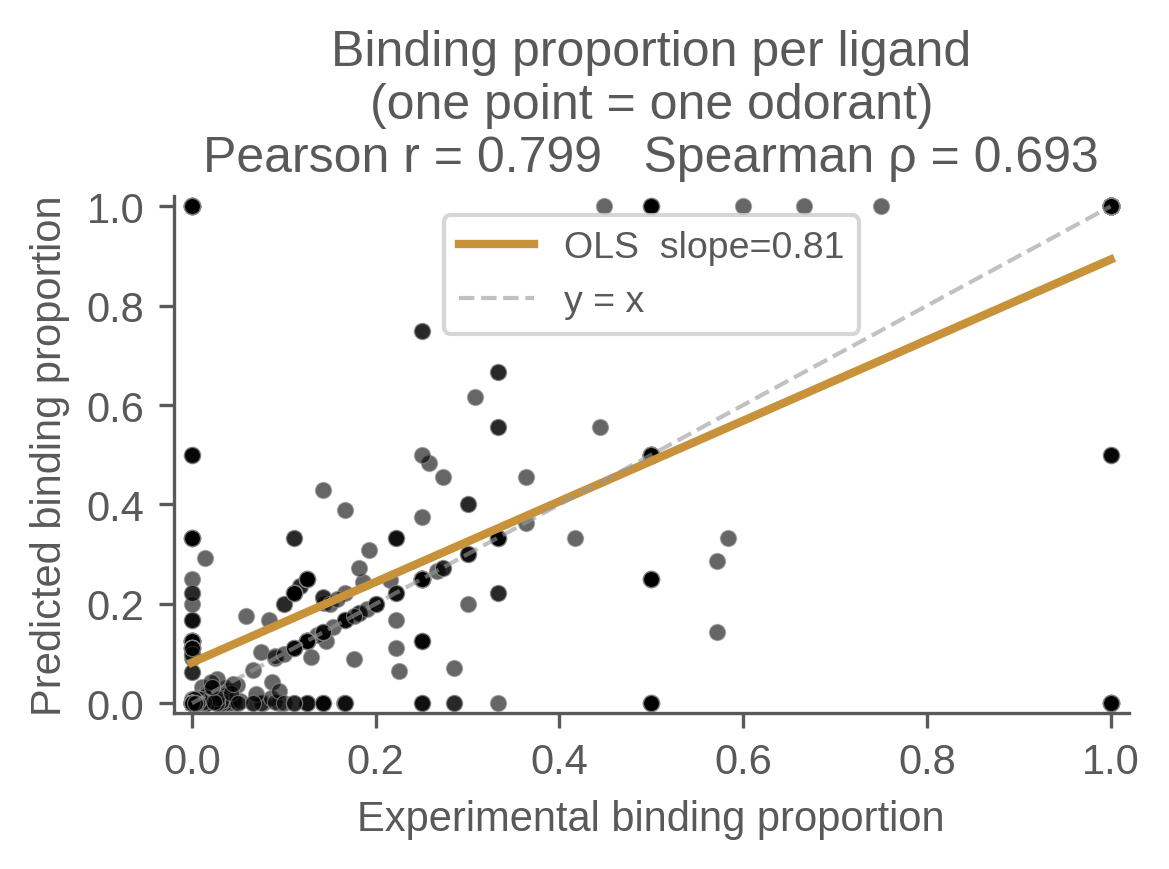

In [6]:
odorant_proportions = (common_pairs.groupby("smiles_id")
                       .agg(exp_prop=("experimental", "mean"), pred_prop=("predicted", "mean"),
                            n_pairs=("experimental", "count"))
                       .reset_index())
af.binding_proportion_scatter(odorant_proportions, "Binding proportion per ligand\n(one point = one odorant)",
                              FIGURES / "proportions_scatter_per_odorant.svg")

## False positives and false negatives

- **FP**: called at the cut, measured as not binding
- **FN**: measured as binding, not called

In [7]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu

CAT_COLORS = af.CONFUSION_COLOURS
CLASS_I_COL, CLASS_II_COL = af.CLASS_I_COLOUR, af.CLASS_II_COLOUR

In [8]:
cp = pd.read_csv(MAIN_TABLES / "exp_pred_common_pairs.csv")

def assign_cm(row):
    if row.experimental == 1 and row.predicted == 1: return 'TP'
    if row.experimental == 0 and row.predicted == 1: return 'FP'
    if row.experimental == 1 and row.predicted == 0: return 'FN'
    return 'TN'

cp['cm_category'] = cp.apply(assign_cm, axis=1)

# Subsets for convenience
fp = cp[cp.cm_category == 'FP']
fn = cp[cp.cm_category == 'FN']
tp = cp[cp.cm_category == 'TP']
tn = cp[cp.cm_category == 'TN']

print(f"Total pairs     : {len(cp):>7,}")
print(f"Unique proteins : {cp.uniprot_id.nunique():>7,}")
print(f"Unique SMILES   : {cp.smiles_id.nunique():>7,}")
print()
print("Confusion matrix:")
for cat in ['TP','FP','TN','FN']:
    n = (cp.cm_category == cat).sum()
    print(f"  {cat}: {n:>6,}  ({n/len(cp)*100:.1f}%)")

Total pairs     :  23,782
Unique proteins :     409
Unique SMILES   :     652

Confusion matrix:
  TP:    672  (2.8%)
  FP:    456  (1.9%)
  TN: 22,198  (93.3%)
  FN:    456  (1.9%)


## Class enrichment

Class I is the smaller, more divergent group. Does it collect more errors?

In [9]:
ct = pd.crosstab(cp.OR_class, cp.cm_category)[['TN','FP','TP','FN']]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Counts:")
print(ct.to_string())
print("\nRow percentages:")
print(ct_pct.round(2).to_string())

chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-square test: χ²={chi2:.2f}, p={p:.2e}, dof={dof}")

# Additional: FP rate per class
for cls in ['class 1', 'class 2']:
    sub = cp[cp.OR_class == cls]
    neg = sub[sub.experimental == 0]
    fp_rate = (neg.predicted == 1).sum() / len(neg) * 100
    print(f"  FP rate in {cls}: {fp_rate:.2f}% ({(neg.predicted==1).sum()}/{len(neg)} negatives)")

Counts:
cm_category     TN   FP   TP   FN
OR_class                         
class 1       2876   82  107  102
class 2      19322  374  565  354

Row percentages:
cm_category     TN    FP    TP    FN
OR_class                            
class 1      90.81  2.59  3.38  3.22
class 2      93.73  1.81  2.74  1.72

Chi-square test: χ²=47.42, p=2.83e-10, dof=3
  FP rate in class 1: 2.77% (82/2958 negatives)
  FP rate in class 2: 1.90% (374/19696 negatives)


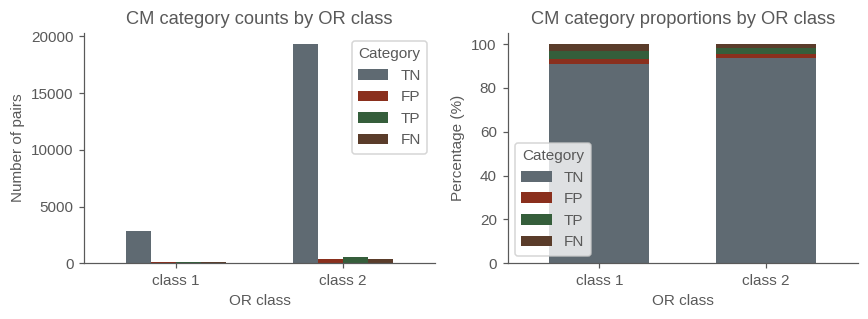

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))

# Stacked bar — raw counts
ct.plot(kind='bar', ax=axes[0], color=[CAT_COLORS[c] for c in ct.columns], width=0.6)
axes[0].set_xlabel('OR class')
axes[0].set_ylabel('Number of pairs')
axes[0].set_title('CM category counts by OR class')
axes[0].set_xticklabels(ct.index, rotation=0)
axes[0].legend(title='Category')

# Stacked bar — percentages (only FP + FN highlighted)
ct_pct.plot(kind='bar', ax=axes[1], color=[CAT_COLORS[c] for c in ct.columns], width=0.6, stacked=True)
axes[1].set_xlabel('OR class')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('CM category proportions by OR class')
axes[1].set_xticklabels(ct_pct.index, rotation=0)
axes[1].legend(title='Category')

plt.tight_layout()
plt.savefig(FIGURES / f'class_cm_distribution.svg', bbox_inches='tight')
plt.show()

## Probability distributions

Where the four categories sit on the probability axis.

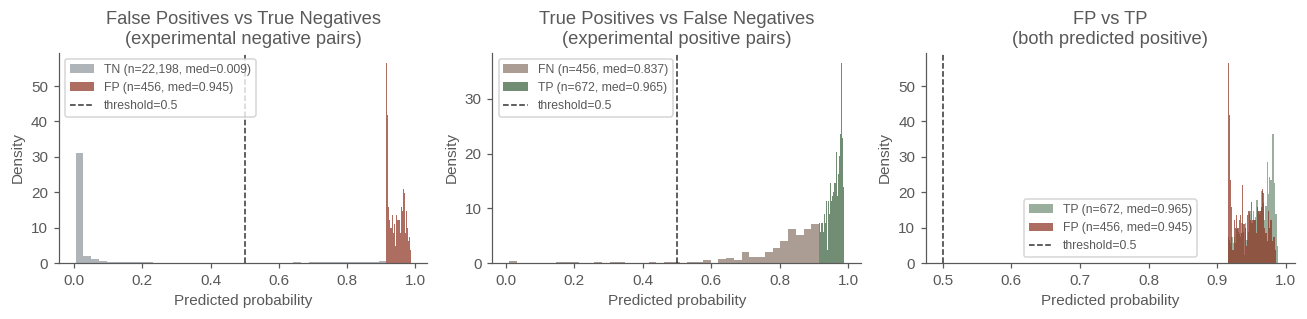

Probability summary by category:
               count    mean     std     min     25%     50%     75%     max
cm_category                                                                 
FN             456.0  0.7849  0.1595  0.0098  0.7627  0.8373  0.8760  0.9148
FP             456.0  0.9446  0.0213  0.9150  0.9229  0.9448  0.9636  0.9863
TN           22198.0  0.1191  0.2427  0.0046  0.0062  0.0091  0.0452  0.9150
TP             672.0  0.9604  0.0196  0.9151  0.9472  0.9649  0.9774  0.9883


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(3 * FIGSIZE[0], FIGSIZE[1]))

comparisons = [
    ('FP', 'TN', 'False Positives vs True Negatives\n(experimental negative pairs)'),
    ('TP', 'FN', 'True Positives vs False Negatives\n(experimental positive pairs)'),
    ('FP', 'TP', 'FP vs TP\n(both predicted positive)'),
]

for ax, (grp1, grp2, title) in zip(axes, comparisons):
    for cat, alpha in [(grp2, 0.5), (grp1, 0.7)]:
        data = cp[cp.cm_category == cat]['probability']
        ax.hist(data, bins=40, alpha=alpha, color=CAT_COLORS[cat],
                label=f'{cat} (n={len(data):,}, med={data.median():.3f})', density=True)
    ax.axvline(0.5, color='k', linestyle='--', lw=1, alpha=0.8, label='threshold=0.5')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / f'probability_distributions.svg', bbox_inches='tight')
plt.show()

# Numeric summary
print("Probability summary by category:")
print(cp.groupby('cm_category')['probability'].describe().round(4).to_string())

## False positives per receptor

Spread across the repertoire, or concentrated in a few receptors?

In [12]:
receptor_stats = cp.groupby('uniprot_id').agg(
    total_pairs  = ('cm_category', 'count'),
    FP_count     = ('cm_category', lambda x: (x == 'FP').sum()),
    TN_count     = ('cm_category', lambda x: (x == 'TN').sum()),
    TP_count     = ('cm_category', lambda x: (x == 'TP').sum()),
    FN_count     = ('cm_category', lambda x: (x == 'FN').sum()),
    OR_class     = ('OR_class', 'first'),
    has_mutation = ('mutation', lambda x: x.any())
).reset_index()

# FP rate = FP / (FP + TN) = FP among negatives
receptor_stats['neg_pairs'] = receptor_stats.FP_count + receptor_stats.TN_count
receptor_stats['FP_rate']   = receptor_stats.FP_count / receptor_stats.neg_pairs
receptor_stats = receptor_stats.sort_values('FP_count', ascending=False)

print(f"Receptors with ≥1 FP : {(receptor_stats.FP_count > 0).sum()} / {len(receptor_stats)}")
print(f"Receptors with ≥1 FN : {(receptor_stats.FN_count > 0).sum()} / {len(receptor_stats)}")
print()
print("Top 20 receptors by FP count:")
display(receptor_stats[['uniprot_id','OR_class','total_pairs','neg_pairs','FP_count','FP_rate','has_mutation']].head(20).to_string(index=False))

Receptors with ≥1 FP : 129 / 409
Receptors with ≥1 FN : 177 / 409

Top 20 receptors by FP count:


'uniprot_id OR_class  total_pairs  neg_pairs  FP_count  FP_rate  has_mutation\n    Q9Y3N9  class 2          295        161        77 0.478261         False\n    P47890  class 2          160        115        39 0.339130         False\n    Q9P1Q5  class 2          321        256        37 0.144531         False\n    P34982  class 2          181         78        26 0.333333         False\n    Q9H346  class 1          162        130        23 0.176923         False\n    O76001  class 2           77         50        16 0.320000         False\n    Q9H255  class 1          196        166        14 0.084337         False\n    Q9Y585  class 2          154        132        11 0.083333         False\n    Q8NGI9  class 2          107         72        10 0.138889         False\n    Q8NHB7  class 2          233        206         9 0.043689         False\n    Q96RD0  class 2           80         72         8 0.111111         False\n    Q8NGN6  class 2           74         50         8 0.160000 

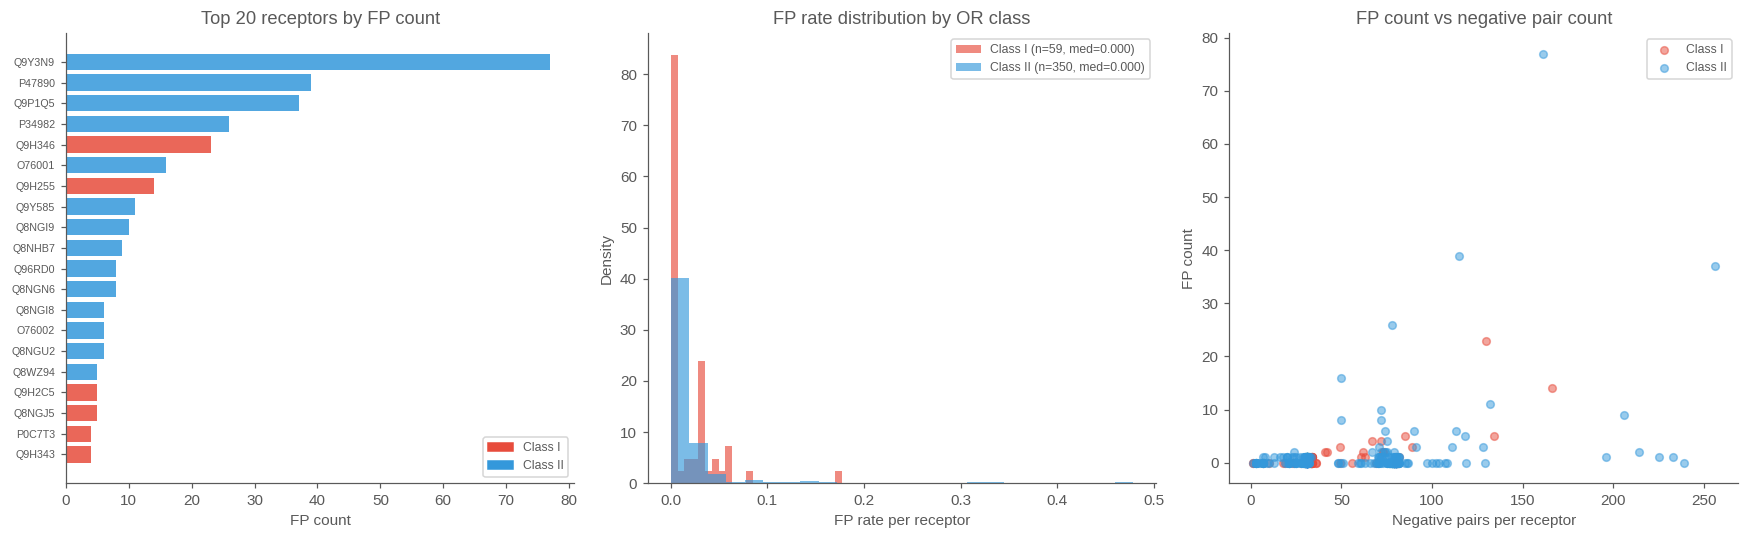

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Top 20 receptors by FP count
top20 = receptor_stats.head(20)
bar_colors = ['#e74c3c' if c == 'class 1' else '#3498db' for c in top20.OR_class]
axes[0].barh(range(20), top20.FP_count.values, color=bar_colors, alpha=0.85)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20.uniprot_id.values, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel('FP count')
axes[0].set_title('Top 20 receptors by FP count')
axes[0].legend(handles=[
    Patch(color='#e74c3c', label='Class I'),
    Patch(color='#3498db', label='Class II')
], loc='lower right', fontsize=8)

# FP rate distribution by class
for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    data = receptor_stats[receptor_stats.OR_class == cls]['FP_rate'].dropna()
    axes[1].hist(data, bins=25, alpha=0.65, color=color,
                 label=f'{label} (n={len(data)}, med={data.median():.3f})', density=True)
axes[1].set_xlabel('FP rate per receptor')
axes[1].set_ylabel('Density')
axes[1].set_title('FP rate distribution by OR class')
axes[1].legend(fontsize=8)

# FP count vs total pairs (scatter)
for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    sub = receptor_stats[receptor_stats.OR_class == cls]
    axes[2].scatter(sub.neg_pairs, sub.FP_count, alpha=0.5, color=color, s=25, label=label)
axes[2].set_xlabel('Negative pairs per receptor')
axes[2].set_ylabel('FP count')
axes[2].set_title('FP count vs negative pair count')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / f'fp_per_receptor.svg', bbox_inches='tight')
plt.show()

## False positives per odorant

The same question from the molecule side.

In [14]:
odorant_stats = cp.groupby('smiles_id').agg(
    total_pairs = ('cm_category', 'count'),
    FP_count    = ('cm_category', lambda x: (x == 'FP').sum()),
    TN_count    = ('cm_category', lambda x: (x == 'TN').sum()),
    TP_count    = ('cm_category', lambda x: (x == 'TP').sum()),
    FN_count    = ('cm_category', lambda x: (x == 'FN').sum()),
    SMILES      = ('SMILES', 'first')
).reset_index()

odorant_stats['neg_pairs'] = odorant_stats.FP_count + odorant_stats.TN_count
odorant_stats['FP_rate']   = odorant_stats.FP_count / odorant_stats.neg_pairs
odorant_stats = odorant_stats.sort_values('FP_count', ascending=False)

print(f"Odorants with ≥1 FP : {(odorant_stats.FP_count > 0).sum()} / {len(odorant_stats)}")
print()
print("Top 20 odorants by FP count:")
pd.set_option('display.max_colwidth', 55)
display(odorant_stats[['smiles_id','total_pairs','FP_count','FP_rate','SMILES']].head(20))

Odorants with ≥1 FP : 192 / 652

Top 20 odorants by FP count:


,smiles_id,total_pairs,FP_count,FP_rate,SMILES
120,SML0120,273,78,0.289963,CC1COCC2=CC3=C(C=C12)C(C(C3(C)C)C)(C)C
103,SML0103,189,18,0.111111,CC(=CCC/C(=C/COC(=O)C)/C)C
135,SML0135,29,16,1.000000,C[C@@H]1CC(=O)C=C2[C@]1(C[C@@H](CC2)C(=C)C)C
110,SML0110,186,16,0.109589,C/C=C/C1=CC(=C(C=C1)O)OC
100,SML0100,188,15,0.098039,CC(=O)OC1=C(C=C(C=C1)CC=C)OC
114,SML0114,188,13,0.080745,C1=CC=C(C=C1)CC=O
99,SML0099,188,11,0.064327,C1CCCCCC(=O)OCCOC(=O)CCCCC1
1,SML0001,364,8,0.022222,CC1=CC[C@@H](CC1=O)C(=C)C
94,SML0094,186,8,0.046512,CC(=CCC/C(=C/C=O)/C)C
17,SML0017,31,7,0.304348,C1=CC=C2C(=C1)C=CC(=O)O2


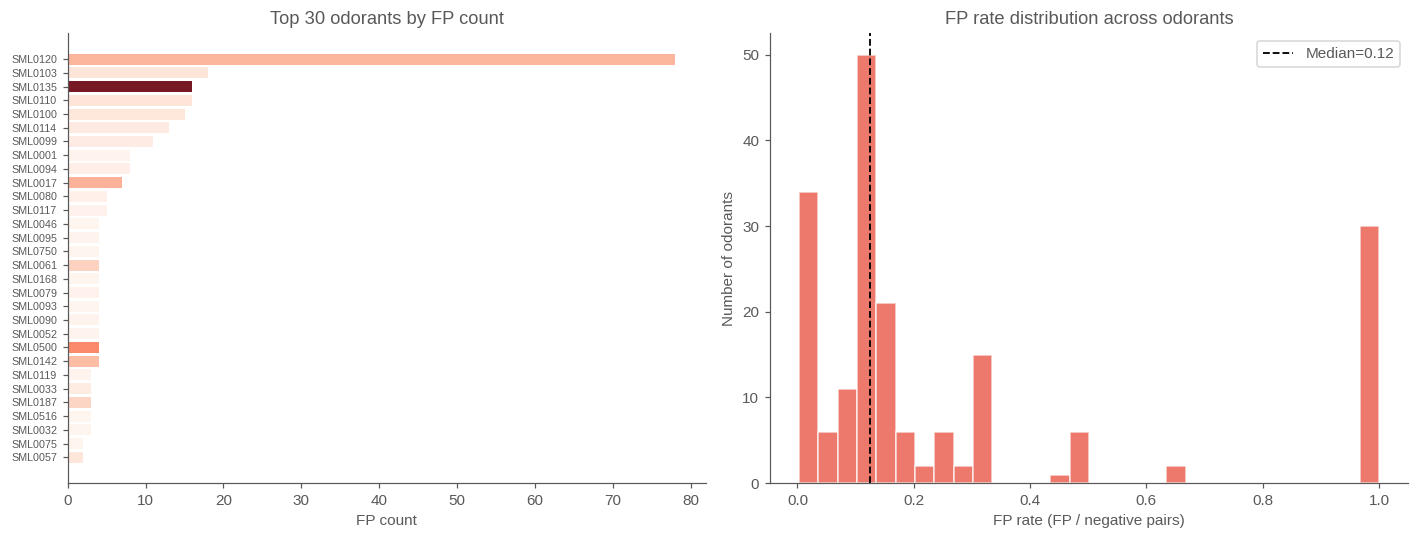

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top 30 odorants by FP count
top30 = odorant_stats.head(30)
cmap_vals = plt.cm.Reds(top30.FP_rate.values / top30.FP_rate.max())
axes[0].barh(range(30), top30.FP_count.values, color=cmap_vals, alpha=0.9)
axes[0].set_yticks(range(30))
axes[0].set_yticklabels(top30.smiles_id.values, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel('FP count')
axes[0].set_title('Top 30 odorants by FP count')

# FP rate histogram across all odorants with ≥1 FP
fp_odo = odorant_stats[odorant_stats.FP_count > 0]
axes[1].hist(fp_odo.FP_rate, bins=30, color='#e74c3c', alpha=0.75, edgecolor='white')
axes[1].axvline(fp_odo.FP_rate.median(), color='k', ls='--', lw=1.2,
               label=f'Median={fp_odo.FP_rate.median():.2f}')
axes[1].set_xlabel('FP rate (FP / negative pairs)')
axes[1].set_ylabel('Number of odorants')
axes[1].set_title('FP rate distribution across odorants')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / f'fp_per_odorant.svg', bbox_inches='tight')
plt.show()

## False negatives

How far below the cut did the missed pairs actually score?

In [16]:
print(f"{len(fn):,} false negatives (confirmed interaction, model predicts none)")
print(f"  unique proteins : {fn.uniprot_id.nunique()}")
print(f"  unique odorants : {fn.smiles_id.nunique()}")
print(f"  OR class        : {fn.OR_class.value_counts().to_dict()}")
print(f"  mutation        : {fn.mutation.value_counts().to_dict()}")
print(f"  probability     : {fn.probability.min():.4f} - {fn.probability.max():.4f} (median {fn.probability.median():.4f})")

# The highest-probability FNs are the ones the threshold only just excluded.
print(f"\nTop 25 by probability (nearest the cut):")
fn_display = (fn[['uniprot_id','OR_class','mutation','smiles_id','SMILES','probability']]
              .sort_values('probability', ascending=False).head(25).reset_index(drop=True))
pd.set_option('display.max_colwidth', 50)
display(fn_display)

456 false negatives (confirmed interaction, model predicts none)
  unique proteins : 177
  unique odorants : 161
  OR class        : {'class 2': 354, 'class 1': 102}
  mutation        : {False: 437, True: 19}
  probability     : 0.0098 - 0.9148 (median 0.8373)

Top 25 by probability (nearest the cut):


,uniprot_id,OR_class,mutation,smiles_id,SMILES,probability
0,Q9P1Q5,class 2,False,SML0027,CC(=CCC/C(=C/CO)/C)C,0.914816
1,Q9H344,class 1,False,SML0125,CCCCC(=O)O,0.914770
2,Q8WZ94,class 2,False,SML0080,CC(=O)C1=CC=CC=C1,0.913814
3,O76002,class 2,False,SML0140,CCCCCCCCCO,0.913500
4,Q96R47,class 2,False,SML0103,CC(=CCC/C(=C/COC(=O)C)/C)C,0.913322
5,Q9P1Q5,class 2,False,SML0150,CC(=CCCC(=CC=O)C)C,0.912997
6,O76001,class 2,False,SML0083,C[C@@H]1CC[C@H]([C@@H](C1)O)C(C)C,0.912988
7,Q8NH73,class 2,False,SML0080,CC(=O)C1=CC=CC=C1,0.912275
8,Q9H343,class 1,False,SML0052,CCCCCCCCCCC=O,0.911870
9,Q9Y585,class 2,False,SML0187,CC1=C(C(CCC1)(C)C)/C=C/C(=O)C,0.911494


In [17]:
# Which proteins appear multiple times in FN pairs?
fn_prot = fn.groupby('uniprot_id').agg(
    FN_count = ('cm_category', 'count'),
    OR_class = ('OR_class', 'first'),
    mutation = ('mutation', lambda x: x.any()),
    odorants = ('smiles_id', lambda x: ', '.join(x.tolist()))
).reset_index().sort_values('FN_count', ascending=False)

print("Proteins in FN pairs (by frequency):")
print(f'{len(fn_prot)} proteins carry at least one FN; showing the top 20')
display(fn_prot.head(20))

# How many of these proteins also have TP pairs?
fn_prots_with_tp = set(fn.uniprot_id) & set(tp.uniprot_id)
print(f"\nFN proteins that also have TP pairs: {len(fn_prots_with_tp)} / {fn.uniprot_id.nunique()}")

Proteins in FN pairs (by frequency):
177 proteins carry at least one FN; showing the top 20


,uniprot_id,FN_count,OR_class,mutation,odorants
169,Q9P1Q5,15,class 2,False,"SML0027, SML0032, SML0046, SML0083, SML0094, S..."
163,Q9H255,13,class 1,False,"SML0015, SML0045, SML0049, SML0069, SML0081, S..."
91,Q8NGN6,12,class 2,False,"SML0029, SML0084, SML0085, SML0086, SML0092, S..."
168,Q9H346,12,class 1,False,"SML0057, SML0089, SML0140, SML0170, SML0197, S..."
145,Q8TCB6,11,class 1,True,"SML0002, SML0003, SML0016, SML0029, SML0080, S..."
159,Q9GZK7,11,class 2,False,"SML0082, SML0083, SML0086, SML0102, SML0119, S..."
175,Q9Y585,11,class 2,False,"SML0000, SML0041, SML0044, SML0089, SML0137, S..."
173,Q9Y3N9,9,class 2,False,"SML0002, SML0009, SML0083, SML0088, SML0115, S..."
148,Q8WZ94,8,class 2,False,"SML0069, SML0080, SML0083, SML0093, SML0112, S..."
21,P47890,8,class 2,False,"SML0041, SML0065, SML0083, SML0196, SML0229, S..."



FN proteins that also have TP pairs: 61 / 177


## Chemistry of misclassified odorants

Do the molecules the model over-calls look different from the ones it gets right?

In [18]:
DESC_COLS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'RingCount', 'AromaticRings']

def compute_descriptors(smiles_str):
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        return {k: np.nan for k in DESC_COLS}
    return {
        'MW'          : Descriptors.MolWt(mol),
        'logP'        : Descriptors.MolLogP(mol),
        'TPSA'        : Descriptors.TPSA(mol),
        'HBD'         : rdMolDescriptors.CalcNumHBD(mol),
        'HBA'         : rdMolDescriptors.CalcNumHBA(mol),
        'RotBonds'    : rdMolDescriptors.CalcNumRotatableBonds(mol),
        'RingCount'   : rdMolDescriptors.CalcNumRings(mol),
        'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)
    }

unique_smiles = cp[['smiles_id','SMILES']].drop_duplicates('smiles_id')
desc_rows = []
for _, row in unique_smiles.iterrows():
    d = compute_descriptors(row.SMILES)
    d['smiles_id'] = row.smiles_id
    desc_rows.append(d)

smiles_desc = pd.DataFrame(desc_rows)
cp_desc = cp.merge(smiles_desc, on='smiles_id', how='left')

print(f"Descriptors computed for {len(smiles_desc)} unique SMILES")
print(f"Failed (None mol): {smiles_desc[DESC_COLS].isna().any(axis=1).sum()}")
print()
print(smiles_desc[DESC_COLS].describe().round(2).to_string())

Descriptors computed for 652 unique SMILES


Failed (None mol): 0

            MW    logP    TPSA     HBD    HBA  RotBonds  RingCount  AromaticRings
count   652.00  652.00  652.00  652.00  652.0    652.00     652.00         652.00
mean    164.06    2.35   28.27    0.50    1.7      3.34       0.76           0.36
std      63.52    1.45   26.98    0.97    1.2      3.15       0.86           0.57
min      44.05   -5.55    0.00    0.00    0.0      0.00       0.00           0.00
25%     130.19    1.59   17.07    0.00    1.0      1.00       0.00           0.00
50%     154.25    2.34   23.79    0.00    1.0      3.00       1.00           0.00
75%     187.52    3.10   34.14    1.00    2.0      5.00       1.00           1.00
max    1060.23    6.81  418.78   12.00   13.0     27.00       5.00           3.00


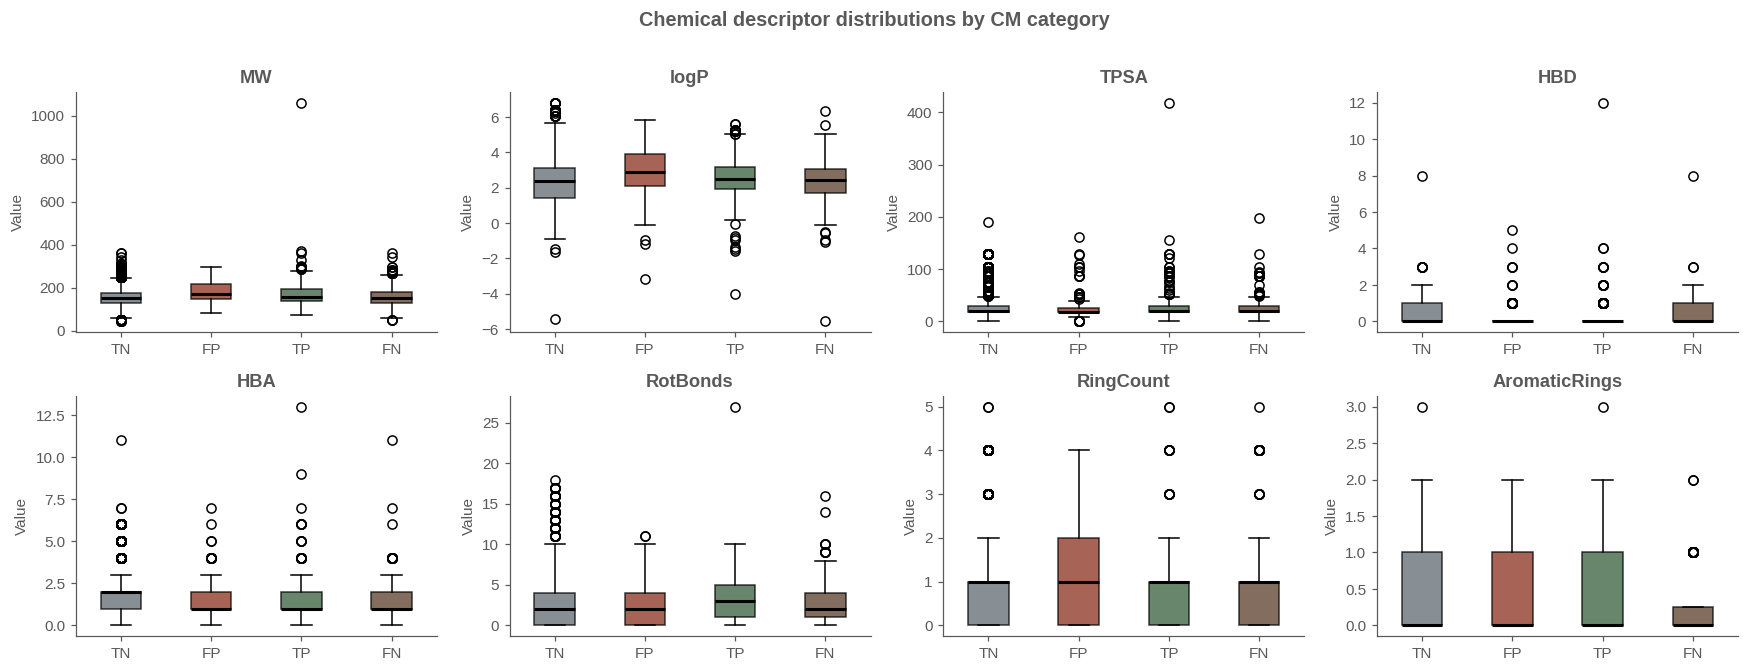

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(4 * FIGSIZE[0], 2 * FIGSIZE[1]))
axes = axes.flatten()

cats_plot = ['TN', 'FP', 'TP', 'FN']

for i, desc in enumerate(DESC_COLS):
    data = [cp_desc[cp_desc.cm_category == cat][desc].dropna().values for cat in cats_plot]
    bp = axes[i].boxplot(data, labels=cats_plot, patch_artist=True, notch=False,
                         medianprops={'color':'black','linewidth':2})
    for patch, cat in zip(bp['boxes'], cats_plot):
        patch.set_facecolor(CAT_COLORS[cat])
        patch.set_alpha(0.75)
    axes[i].set_title(desc, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Chemical descriptor distributions by CM category', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / f'chemical_descriptors_by_cm.svg', bbox_inches='tight')
plt.show()

In [20]:
print("Mann-Whitney U test: FP vs TN odorant chemical properties")
print(f"{'Descriptor':<14} {'FP_median':>10} {'TN_median':>10} {'p-value':>12} {'sig':>5}")
print("-" * 55)
for desc in DESC_COLS:
    fp_d = cp_desc[cp_desc.cm_category == 'FP'][desc].dropna()
    tn_d = cp_desc[cp_desc.cm_category == 'TN'][desc].dropna()
    _, p = mannwhitneyu(fp_d, tn_d, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{desc:<14} {fp_d.median():>10.3f} {tn_d.median():>10.3f} {p:>12.4e} {sig:>5}")

print()
print("Kruskal-Wallis test across all four CM categories:")
print(f"{'Descriptor':<14} {'H':>8} {'p-value':>12} {'sig':>5}")
print("-" * 42)
for desc in DESC_COLS:
    groups = [cp_desc[cp_desc.cm_category == cat][desc].dropna().values for cat in cats_plot]
    h, p = kruskal(*groups)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{desc:<14} {h:>8.2f} {p:>12.4e} {sig:>5}")

Mann-Whitney U test: FP vs TN odorant chemical properties
Descriptor      FP_median  TN_median      p-value   sig
-------------------------------------------------------
MW                170.296    154.253   4.7924e-20   ***
logP                2.878      2.361   1.8590e-21   ***
TPSA               18.460     20.230   4.8900e-07   ***
HBD                 0.000      0.000   2.0289e-13   ***
HBA                 1.000      2.000   2.9279e-05   ***
RotBonds            2.000      2.000   4.0219e-03    **
RingCount           1.000      1.000   3.4815e-09   ***
AromaticRings       0.000      0.000   3.4923e-21   ***

Kruskal-Wallis test across all four CM categories:
Descriptor            H      p-value   sig
------------------------------------------
MW               111.47   5.3037e-24   ***
logP             132.56   1.5166e-28   ***
TPSA              25.54   1.1887e-05   ***
HBD               97.30   5.9164e-21   ***
HBA               42.97   2.4977e-09   ***
RotBonds         116.88   3.6

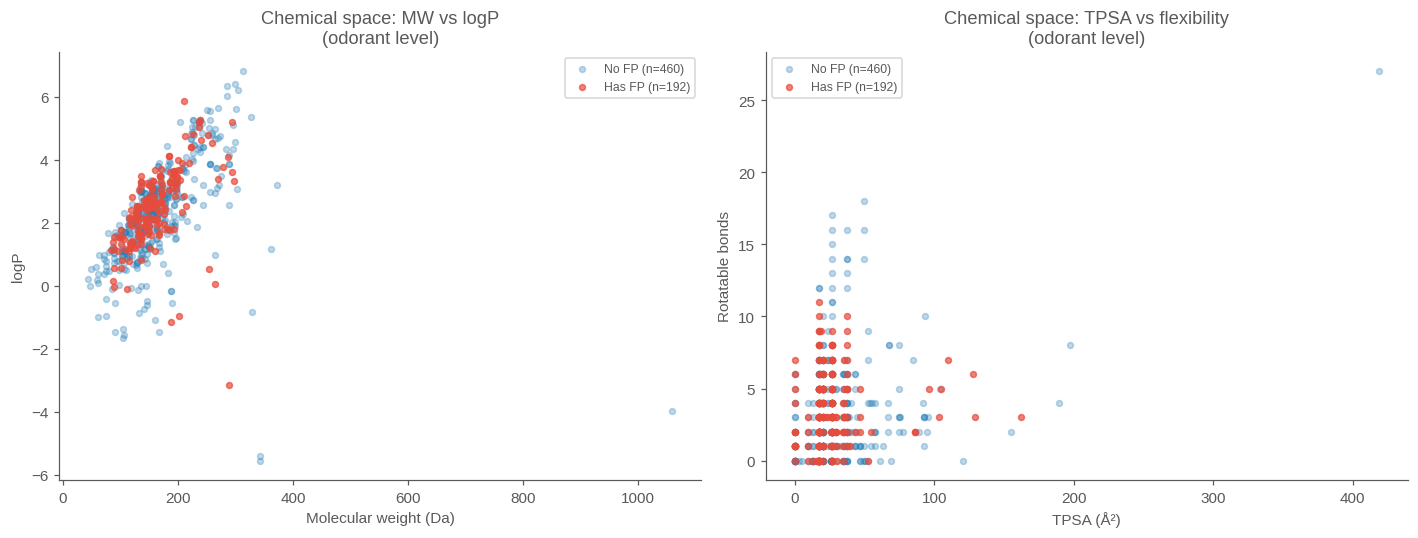

In [21]:
# Chemical space 2D — FP vs TN odorants at the unique-SMILES level
# Aggregate: each SMILES gets the category of its most frequent pair type
smiles_cat = cp_desc.groupby('smiles_id').agg(
    FP_count = ('cm_category', lambda x: (x=='FP').sum()),
    TN_count = ('cm_category', lambda x: (x=='TN').sum()),
).reset_index()
smiles_cat['dominant'] = np.where(smiles_cat.FP_count > smiles_cat.TN_count, 'FP-dominant', 'TN-dominant')
# Odorants with any FP vs purely TN
smiles_cat['has_FP'] = smiles_cat.FP_count > 0

plot_df = smiles_cat.merge(smiles_desc, on='smiles_id')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for has_fp, label, color, alpha in [
    (False, 'No FP',  '#2980b9', 0.3),
    (True,  'Has FP', '#e74c3c', 0.7)
]:
    sub = plot_df[plot_df.has_FP == has_fp]
    axes[0].scatter(sub.MW, sub.logP, c=color, alpha=alpha, s=15, label=f'{label} (n={len(sub)})')
axes[0].set_xlabel('Molecular weight (Da)')
axes[0].set_ylabel('logP')
axes[0].set_title('Chemical space: MW vs logP\n(odorant level)')
axes[0].legend(fontsize=8)

for has_fp, label, color, alpha in [
    (False, 'No FP',  '#2980b9', 0.3),
    (True,  'Has FP', '#e74c3c', 0.7)
]:
    sub = plot_df[plot_df.has_FP == has_fp]
    axes[1].scatter(sub.TPSA, sub.RotBonds, c=color, alpha=alpha, s=15, label=f'{label} (n={len(sub)})')
axes[1].set_xlabel('TPSA (Å²)')
axes[1].set_ylabel('Rotatable bonds')
axes[1].set_title('Chemical space: TPSA vs flexibility\n(odorant level)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / f'chemical_space_fp_vs_tn.svg', bbox_inches='tight')
plt.show()

## Receptor-level view

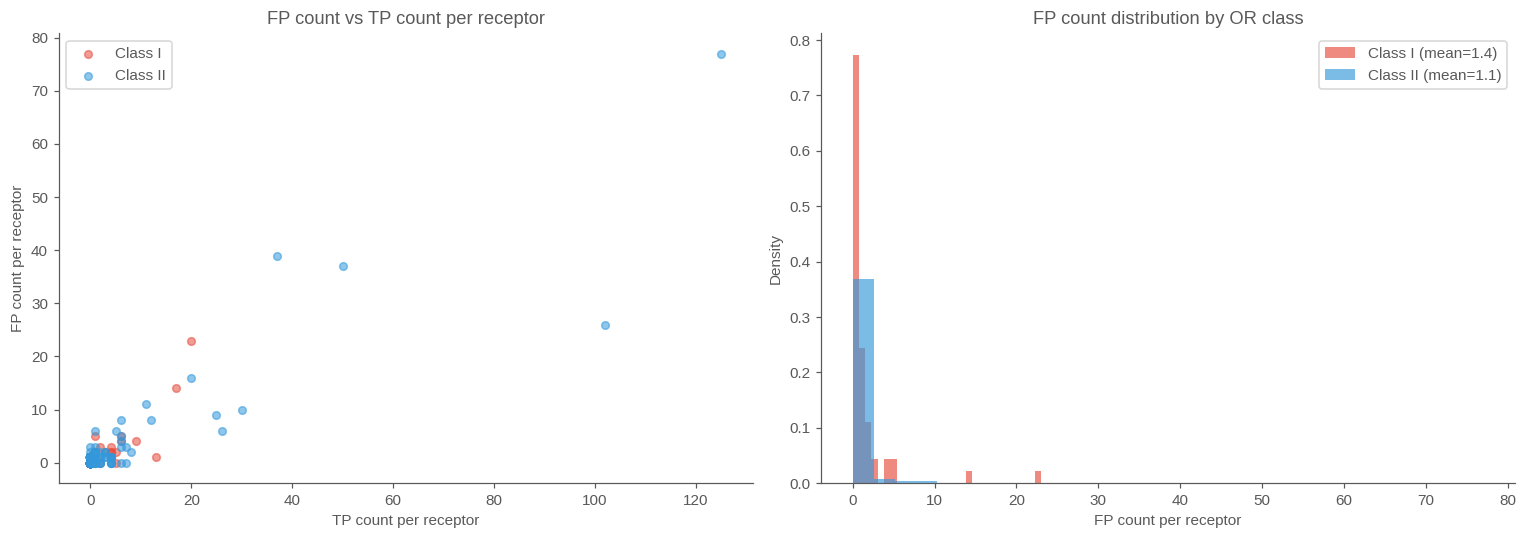

FP rate: Class I median=0.0000, Class II median=0.0000
Mann-Whitney U p=1.0216e-01


In [22]:
# Focus on receptors with at least one FP
fp_receptors = receptor_stats[receptor_stats.FP_count > 0].sort_values(
    ['OR_class', 'FP_count'], ascending=[True, False]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FP count vs TP count per receptor (scatter)
for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    sub = receptor_stats[receptor_stats.OR_class == cls]
    axes[0].scatter(sub.TP_count, sub.FP_count, alpha=0.55, color=color, s=25, label=label)
axes[0].set_xlabel('TP count per receptor')
axes[0].set_ylabel('FP count per receptor')
axes[0].set_title('FP count vs TP count per receptor')
axes[0].legend()

# Distribution of FP counts (log scale)
for cls, color, label in [('class 1','#e74c3c','Class I'), ('class 2','#3498db','Class II')]:
    data = receptor_stats[receptor_stats.OR_class == cls]['FP_count']
    axes[1].hist(data, bins=30, alpha=0.65, color=color, density=True,
                label=f'{label} (mean={data.mean():.1f})')
axes[1].set_xlabel('FP count per receptor')
axes[1].set_ylabel('Density')
axes[1].set_title('FP count distribution by OR class')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / f'receptor_fp_tp_scatter.svg', bbox_inches='tight')
plt.show()

# Wilcoxon rank-sum: Class I vs Class II FP rate
c1_fprate = receptor_stats[receptor_stats.OR_class == 'class 1']['FP_rate'].dropna()
c2_fprate = receptor_stats[receptor_stats.OR_class == 'class 2']['FP_rate'].dropna()
_, p_fprate = mannwhitneyu(c1_fprate, c2_fprate, alternative='two-sided')
print(f"FP rate: Class I median={c1_fprate.median():.4f}, Class II median={c2_fprate.median():.4f}")
print(f"Mann-Whitney U p={p_fprate:.4e}")

## Summary

In [23]:
print("=" * 70)
print("SUMMARY OF FP/FN EXPLORATION")
print("=" * 70)

print(f"""
Dataset
  Total pairs      : {len(cp):,}
  Unique proteins  : {cp.uniprot_id.nunique()}
  Unique odorants  : {cp.smiles_id.nunique()}

Confusion matrix
  TP : {len(tp):>6,}  ({len(tp)/len(cp)*100:.1f}%)
  TN : {len(tn):>6,}  ({len(tn)/len(cp)*100:.1f}%)
  FP : {len(fp):>6,}  ({len(fp)/len(cp)*100:.1f}%)
  FN : {len(fn):>6,}  ({len(fn)/len(cp)*100:.1f}%)

False Positives ({len(fp):,} pairs)
  Receptors with ≥1 FP  : {(receptor_stats.FP_count>0).sum()} / {len(receptor_stats)}
  Odorants with ≥1 FP   : {(odorant_stats.FP_count>0).sum()} / {len(odorant_stats)}
  FP prob range          : {fp.probability.min():.3f} – {fp.probability.max():.3f} (med={fp.probability.median():.3f})

False Negatives ({len(fn)} pairs)
  Unique proteins        : {fn.uniprot_id.nunique()}
  Unique odorants        : {fn.smiles_id.nunique()}
  FN prob range          : {fn.probability.min():.3f} – {fn.probability.max():.3f} (med={fn.probability.median():.3f})
""")

SUMMARY OF FP/FN EXPLORATION

Dataset
  Total pairs      : 23,782
  Unique proteins  : 409
  Unique odorants  : 652

Confusion matrix
  TP :    672  (2.8%)
  TN : 22,198  (93.3%)
  FP :    456  (1.9%)
  FN :    456  (1.9%)

False Positives (456 pairs)
  Receptors with ≥1 FP  : 129 / 409
  Odorants with ≥1 FP   : 192 / 652
  FP prob range          : 0.915 – 0.986 (med=0.945)

False Negatives (456 pairs)
  Unique proteins        : 177
  Unique odorants        : 161
  FN prob range          : 0.010 – 0.915 (med=0.837)



## Phylogenetic distance

Three questions about where the errors sit on the tree:

1. Are FP receptors closer to true binders of the same odorant than TN receptors are?
2. Are FP-prone receptors clustered together, or scattered?
3. Does a receptor's distance from everything else predict its FP rate?

In [24]:
# ── Patristic branch distances between the 433 human receptors ───────────────
#
# Computed from the tree committed in this repository, not loaded from a
# precomputed .npy outside it, so this section runs on a fresh clone.
#
# The result is numerically identical to the matrix the earlier version read
# (max |difference| 3.6e-15): that matrix was built from this same tree.
from ete4 import Tree

TREE_FILE = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"

tree = Tree(open(TREE_FILE).read(), parser=0)
tree_leaves = [leaf.name for leaf in tree.leaves()]
leaf_index = {name: i for i, name in enumerate(tree_leaves)}

# Distance from the root to every node, in one pre-order pass.
depth = {}
for node in tree.traverse("preorder"):
    depth[node] = 0.0 if node.up is None else depth[node.up] + float(node.dist)
leaf_depth = np.array([depth[leaf] for leaf in tree.leaves()])

# Patristic distance is depth(a) + depth(b) - 2*depth(mrca). Visiting each
# internal node once and pairing its children's leaf sets reaches every pair
# exactly at its MRCA, so the whole matrix costs one tree walk.
branch_dist = np.zeros((len(tree_leaves), len(tree_leaves)))
for node in tree.traverse("postorder"):
    if node.is_leaf:
        continue
    child_leaves = [[leaf_index[leaf.name] for leaf in child.leaves()]
                    for child in node.children]
    for a in range(len(child_leaves)):
        for b in range(a + 1, len(child_leaves)):
            left, right = np.array(child_leaves[a]), np.array(child_leaves[b])
            block = (leaf_depth[left][:, None] + leaf_depth[right][None, :]
                     - 2 * depth[node])
            branch_dist[np.ix_(left, right)] = block
            branch_dist[np.ix_(right, left)] = block.T

# uniprot -> matrix-row index, stripping the taxid prefix
leaf_to_idx = {name.replace('9606.', ''): i for i, name in enumerate(tree_leaves)}

# Verify all proteins in common_pairs are present
cp_proteins = cp.uniprot_id.unique()
missing = [p for p in cp_proteins if p not in leaf_to_idx]
print(f"Tree leaves       : {len(tree_leaves)}")
print(f"Proteins in CSV   : {len(cp_proteins)}")
print(f"Missing from tree : {len(missing)}")

Tree leaves       : 433
Proteins in CSV   : 409
Missing from tree : 0


In [25]:
# ── Analysis 1: Per-odorant cross-distances ──────────────────────────────────
#
# For each odorant, collect branch distances between:
#   FP receptors ↔ TP receptors  (false-positive receptors vs true binders)
#   TN receptors ↔ TP receptors  (true-negative receptors vs true binders)  ← baseline
#   FN receptors ↔ TP receptors  (missed positives vs confirmed binders)
#
# Hypothesis: FP receptors are phylogenetically closer to TP receptors than
# TN receptors are, suggesting the model is confused by evolutionary similarity.

from itertools import product as iterprod

cross_fp_tp, cross_tn_tp, cross_fn_tp = [], [], []

for smiles_id, grp in cp.groupby('smiles_id'):
    idx_fp = [leaf_to_idx[u] for u in grp.loc[grp.cm_category=='FP','uniprot_id'] if u in leaf_to_idx]
    idx_tp = [leaf_to_idx[u] for u in grp.loc[grp.cm_category=='TP','uniprot_id'] if u in leaf_to_idx]
    idx_tn = [leaf_to_idx[u] for u in grp.loc[grp.cm_category=='TN','uniprot_id'] if u in leaf_to_idx]
    idx_fn = [leaf_to_idx[u] for u in grp.loc[grp.cm_category=='FN','uniprot_id'] if u in leaf_to_idx]

    if idx_tp:
        if idx_fp:
            cross_fp_tp.extend(branch_dist[i, j] for i, j in iterprod(idx_fp, idx_tp) if i != j)
        if idx_tn:
            cross_tn_tp.extend(branch_dist[i, j] for i, j in iterprod(idx_tn, idx_tp) if i != j)
        if idx_fn:
            cross_fn_tp.extend(branch_dist[i, j] for i, j in iterprod(idx_fn, idx_tp) if i != j)

cross_fp_tp = np.array(cross_fp_tp)
cross_tn_tp = np.array(cross_tn_tp)
cross_fn_tp = np.array(cross_fn_tp)

print(f"Cross-distances computed:")
print(f"  FP↔TP : {len(cross_fp_tp):,}  (median={np.median(cross_fp_tp):.4f})")
print(f"  TN↔TP : {len(cross_tn_tp):,}  (median={np.median(cross_tn_tp):.4f})")
print(f"  FN↔TP : {len(cross_fn_tp):,}  (median={np.median(cross_fn_tp):.4f})")

_, p_fp_tn = mannwhitneyu(cross_fp_tp, cross_tn_tp, alternative='two-sided')
print(f"\nMann-Whitney U (FP↔TP vs TN↔TP): p={p_fp_tn:.4e}")

Cross-distances computed:


  FP↔TP : 2,693  (median=3.7926)
  TN↔TP : 47,742  (median=3.6382)
  FN↔TP : 1,128  (median=3.6830)

Mann-Whitney U (FP↔TP vs TN↔TP): p=2.4456e-11


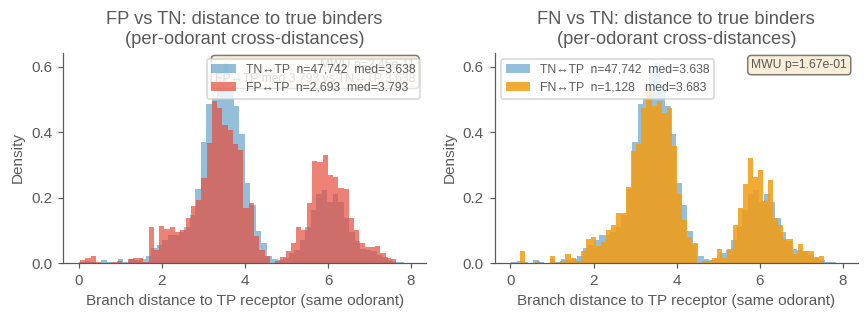

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))

# Panel 1: FP↔TP vs TN↔TP
for data, label, color, alpha in [
    (cross_tn_tp, f'TN↔TP  n={len(cross_tn_tp):,}  med={np.median(cross_tn_tp):.3f}', '#2980b9', 0.5),
    (cross_fp_tp, f'FP↔TP  n={len(cross_fp_tp):,}  med={np.median(cross_fp_tp):.3f}', '#e74c3c', 0.7),
]:
    axes[0].hist(data, bins=60, density=True, alpha=alpha, color=color, label=label)
axes[0].set_xlabel('Branch distance to TP receptor (same odorant)')
axes[0].set_ylabel('Density')
axes[0].set_title('FP vs TN: distance to true binders\n(per-odorant cross-distances)')
axes[0].legend(fontsize=8)

# Two-sided: the direction of this effect depends on the threshold, so a
# one-sided test would silently report p=1 whenever it flips.
_, p_fp_tn2 = mannwhitneyu(cross_fp_tp, cross_tn_tp, alternative='two-sided')
axes[0].text(0.97, 0.97, f'MWU p={p_fp_tn2:.2e}\nFP↔TP med {np.median(cross_fp_tp):.3f} vs TN↔TP {np.median(cross_tn_tp):.3f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel 2: FN↔TP vs TN↔TP
for data, label, color, alpha in [
    (cross_tn_tp, f'TN↔TP  n={len(cross_tn_tp):,}  med={np.median(cross_tn_tp):.3f}', '#2980b9', 0.5),
    (cross_fn_tp, f'FN↔TP  n={len(cross_fn_tp):,}   med={np.median(cross_fn_tp):.3f}', '#f39c12', 0.85),
]:
    axes[1].hist(data, bins=60, density=True, alpha=alpha, color=color, label=label)
axes[1].set_xlabel('Branch distance to TP receptor (same odorant)')
axes[1].set_ylabel('Density')
axes[1].set_title('FN vs TN: distance to true binders\n(per-odorant cross-distances)')
axes[1].legend(fontsize=8)

_, p_fn_tn2 = mannwhitneyu(cross_fn_tp, cross_tn_tp, alternative='two-sided')
axes[1].text(0.97, 0.97, f'MWU p={p_fn_tn2:.2e}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES / f'phylo_cross_distances_per_odorant.svg', bbox_inches='tight')
plt.show()

In [27]:
# ── Analysis 2: Within-category pooled pairwise distances ────────────────────
#
# Pool unique receptors that appear in at least one pair of each CM category
# (a receptor can belong to multiple pools). Compute all pairwise branch
# distances within each pool and compare distributions.
# Question: are FP-prone receptors phylogenetically clustered or dispersed?

from scipy.stats import spearmanr

pool_idxs = {}
for cat in ['TN', 'FP', 'TP', 'FN']:
    uniprots = cp[cp.cm_category == cat]['uniprot_id'].unique()
    pool_idxs[cat] = [leaf_to_idx[u] for u in uniprots if u in leaf_to_idx]
    print(f"  {cat}: {len(pool_idxs[cat])} unique receptors")

print()
within_dists = {}
for cat, idxs in pool_idxs.items():
    dists = [branch_dist[idxs[a], idxs[b]]
             for a in range(len(idxs)) for b in range(a+1, len(idxs))]
    within_dists[cat] = np.array(dists)
    print(f"  {cat}: {len(dists):,} within-pool pairs  "
          f"median={np.median(dists):.4f}  mean={np.mean(dists):.4f}")

print()
print("Mann-Whitney U tests (vs TN pool as baseline):")
tn_d = within_dists['TN']
for cat in ['FP', 'TP', 'FN']:
    _, p = mannwhitneyu(within_dists[cat], tn_d, alternative='two-sided')
    print(f"  {cat} vs TN: p={p:.4e}")

  TN: 409 unique receptors
  FP: 129 unique receptors
  TP: 69 unique receptors
  FN: 177 unique receptors

  TN: 83,436 within-pool pairs  median=3.5852  mean=3.9711
  FP: 8,256 within-pool pairs  median=3.6048  mean=4.1247
  TP: 2,346 within-pool pairs  median=3.7506  mean=4.3610
  FN: 15,576 within-pool pairs  median=3.6123  mean=4.0861

Mann-Whitney U tests (vs TN pool as baseline):
  FP vs TN: p=4.5173e-11
  TP vs TN: p=3.6532e-24
  FN vs TN: p=4.9780e-13


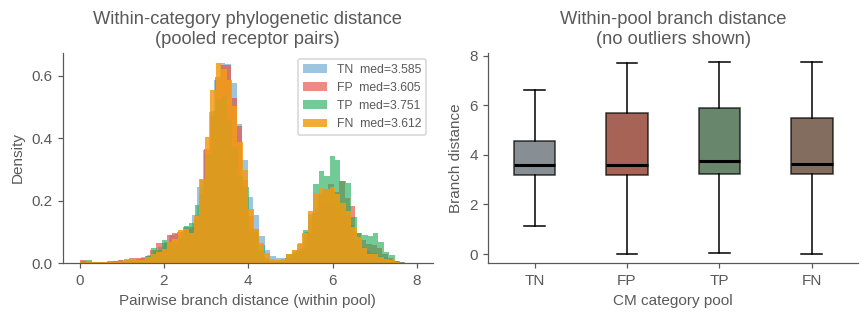

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))

# Panel 1: overlapping histograms of within-pool distances
for cat, color, alpha in [('TN','#2980b9',0.45), ('FP','#e74c3c',0.65),
                           ('TP','#27ae60',0.65), ('FN','#f39c12',0.85)]:
    d = within_dists[cat]
    axes[0].hist(d, bins=60, density=True, alpha=alpha, color=color,
                 label=f'{cat}  med={np.median(d):.3f}')
axes[0].set_xlabel('Pairwise branch distance (within pool)')
axes[0].set_ylabel('Density')
axes[0].set_title('Within-category phylogenetic distance\n(pooled receptor pairs)')
axes[0].legend(fontsize=8)

# Panel 2: boxplot summary
bp_data  = [within_dists[c] for c in ['TN','FP','TP','FN']]
bp = axes[1].boxplot(bp_data, labels=['TN','FP','TP','FN'], patch_artist=True,
                     medianprops={'color':'black','linewidth':2}, showfliers=False)
for patch, cat in zip(bp['boxes'], ['TN','FP','TP','FN']):
    patch.set_facecolor(CAT_COLORS[cat]); patch.set_alpha(0.75)
axes[1].set_xlabel('CM category pool')
axes[1].set_ylabel('Branch distance')
axes[1].set_title('Within-pool branch distance\n(no outliers shown)')

plt.tight_layout()
plt.savefig(FIGURES / f'phylo_within_pool_distances.svg', bbox_inches='tight')
plt.show()

Spearman ρ (mean branch dist vs FP rate): 0.0413  p=4.0512e-01
Spearman ρ (mean branch dist vs TP rate): 0.0741  p=1.3472e-01


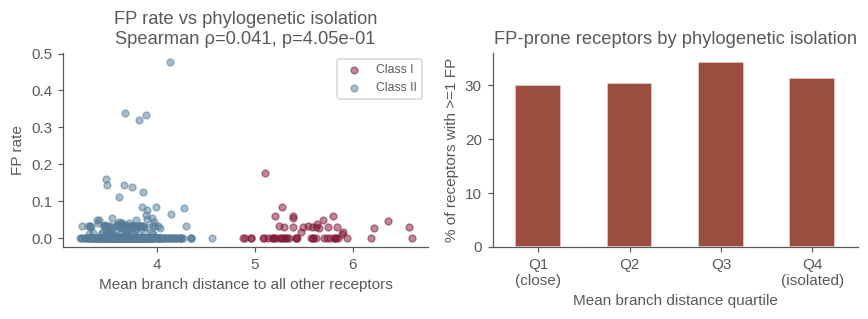

In [29]:
# ── Analysis 3: Per-receptor mean branch distance vs FP rate ─────────────────
#
# For each receptor in common_pairs, compute its mean branch distance to all
# other receptors in the same 409-protein set, then correlate with FP rate.
# Hypothesis: phylogenetically isolated receptors may generate more FPs because
# the model has fewer similar sequences to learn from.

cp_prot_list = list(cp_proteins)
cp_prot_idxs = [leaf_to_idx[u] for u in cp_prot_list]

mean_branch = {}
for i, u in enumerate(cp_prot_list):
    row_vals = [branch_dist[cp_prot_idxs[i], cp_prot_idxs[j]]
                for j in range(len(cp_prot_list)) if i != j]
    mean_branch[u] = np.mean(row_vals)

receptor_stats['mean_branch_dist'] = receptor_stats['uniprot_id'].map(mean_branch)
receptor_stats['TP_rate'] = receptor_stats['TP_count'] / receptor_stats['total_pairs']

rho_fp, p_fp = spearmanr(receptor_stats['mean_branch_dist'], receptor_stats['FP_rate'])
rho_tp, p_tp = spearmanr(receptor_stats['mean_branch_dist'], receptor_stats['TP_rate'])

print(f"Spearman ρ (mean branch dist vs FP rate): {rho_fp:.4f}  p={p_fp:.4e}")
print(f"Spearman ρ (mean branch dist vs TP rate): {rho_tp:.4f}  p={p_tp:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))

for cls, color, label in [('class 1',CLASS_I_COL,'Class I'), ('class 2',CLASS_II_COL,'Class II')]:
    sub = receptor_stats[receptor_stats.OR_class == cls]
    axes[0].scatter(sub.mean_branch_dist, sub.FP_rate,
                    alpha=0.5, color=color, s=20, label=label)
axes[0].set_xlabel('Mean branch distance to all other receptors')
axes[0].set_ylabel('FP rate')
axes[0].set_title(f'FP rate vs phylogenetic isolation\nSpearman ρ={rho_fp:.3f}, p={p_fp:.2e}')
axes[0].legend(fontsize=8)

receptor_stats['bd_quartile'] = pd.qcut(receptor_stats['mean_branch_dist'], 4,
                                         labels=['Q1\n(close)', 'Q2', 'Q3', 'Q4\n(isolated)'])
# 68% of receptors have FP_rate exactly 0 at this threshold, so a quartile
# median is 0 everywhere. Plot the share that produce any FP instead.
q_share = receptor_stats.groupby('bd_quartile', observed=True)['FP_count'].apply(lambda x: 100 * (x > 0).mean())
q_share.plot(kind='bar', ax=axes[1], color=CAT_COLORS['FP'], alpha=0.85, width=0.5, edgecolor='white')
axes[1].set_xlabel('Mean branch distance quartile')
axes[1].set_ylabel('% of receptors with >=1 FP')
axes[1].set_title('FP-prone receptors by phylogenetic isolation')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / f'phylo_mean_dist_vs_fp_rate.svg', bbox_inches='tight')
plt.show()